# LSTM Model Development for Binary Classification

## Import Python's Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd

## Loading and Reshaping Data

In [2]:
data = np.load("../../../data/ukb_processed/train/binary_classification_data.npy")     # load datas
label = np.load("../../../data/ukb_processed/train/binary_classification_label.npy")   # load labels

x = data.reshape(data.shape[0], data.shape[1], 1)
y = label
print(f"Binary Classification Dataset: {x.shape}, Labels: {np.unique(y)}")

Binary Classification Dataset: (450, 4097, 1), Labels: [0 1]


## Train Data using LSTM

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (confusion_matrix, precision_score, recall_score, f1_score, 
                           accuracy_score, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

# Create directories for results
os.makedirs('cv_results', exist_ok=True)
os.makedirs('cv_results/models', exist_ok=True)
os.makedirs('cv_results/training_logs', exist_ok=True)

# Initialize
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold_results = []
confusion_matrices = []
all_histories = []
all_roc_data = []
class_names = ['Negative', 'Positive']

# Initialize lists for detailed training logs
training_logs = []
epoch_by_epoch_data = []

print("Starting 10-Fold Cross Validation for Binary Classification...")
print("=" * 60)

for fold_no, (train_index, val_index) in enumerate(skf.split(x, y), 1):
    print(f"\n🔄 Processing Fold {fold_no}/10")
    
    # Split data
    X_train_fold, X_val_fold = x[train_index], x[val_index]
    y_train_fold, y_val_fold = y[train_index], y[val_index]
    
    # Custom callback
    class myCallback(tf.keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs={}):
            if((logs.get('val_accuracy') > 0.97) and (logs.get('accuracy') > 0.97)):
                print(f"\n✅ Target reached at epoch {epoch + 1}")
                self.model.stop_training = True
    
    # Build model - Same architecture, output for binary classification
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(x.shape[1], 1)),
        Dropout(0.2),
        LSTM(64),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    
    # Binary crossentropy for binary classification
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    
    # Train model
    start_time = time.time()
    history = model.fit(X_train_fold, y_train_fold, 
                        epochs=20, batch_size=30, 
                        validation_data=(X_val_fold, y_val_fold),
                        callbacks=[myCallback()], verbose=1)
    
    training_time = time.time() - start_time
    
    # Evaluate
    scores = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    val_loss, val_accuracy = scores
    
    # Predictions
    y_pred_proba = model.predict(X_val_fold, verbose=0).ravel()
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    # Calculate metrics
    precision = precision_score(y_val_fold, y_pred)
    recall = recall_score(y_val_fold, y_pred)
    f1 = f1_score(y_val_fold, y_pred)
    auc = roc_auc_score(y_val_fold, y_pred_proba)
    
    # Additional binary classification metrics
    cm = confusion_matrix(y_val_fold, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Same as recall
    
    # Store results
    fold_result = {
        'Fold': fold_no,
        'Val_Accuracy': val_accuracy,
        'Val_Loss': val_loss,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'AUC': auc,
        'Specificity': specificity,
        'Sensitivity': sensitivity,
        'True_Negatives': tn,
        'False_Positives': fp,
        'False_Negatives': fn,
        'True_Positives': tp,
        'Training_Time': training_time,
        'Epochs_Trained': len(history.history['loss'])
    }
    
    fold_results.append(fold_result)
    confusion_matrices.append(cm)
    all_histories.append(history.history)
    
    # Store ROC data
    fpr, tpr, _ = roc_curve(y_val_fold, y_pred_proba)
    all_roc_data.append({'fpr': fpr, 'tpr': tpr, 'auc': auc})
    
    # Save model for this fold
    model_filename = f'cv_results/models/lstm_binary_fold_{fold_no}.h5'
    model.save(model_filename)
    print(f"   💾 Model saved: {model_filename}")
    
    # ==================== LOG TRAINING HISTORY ====================
    # Log detailed training history for this fold
    fold_training_log = {
        'fold': fold_no,
        'epochs_completed': len(history.history['loss']),
        'final_train_loss': history.history['loss'][-1],
        'final_train_accuracy': history.history['accuracy'][-1], 
        'final_val_loss': history.history['val_loss'][-1],
        'final_val_accuracy': history.history['val_accuracy'][-1],
        'best_val_accuracy': max(history.history['val_accuracy']),
        'best_val_accuracy_epoch': np.argmax(history.history['val_accuracy']) + 1,
        'min_val_loss': min(history.history['val_loss']),
        'min_val_loss_epoch': np.argmin(history.history['val_loss']) + 1,
        'overfitting_gap': history.history['accuracy'][-1] - history.history['val_accuracy'][-1],
        'early_stopped': len(history.history['loss']) < 20,
        'training_time': training_time,
        'classification_type': 'binary',
        'num_classes': 2,
        'negative_count': tn + fp,
        'positive_count': tp + fn,
        'convergence_speed': np.argmax(history.history['val_accuracy']) + 1,
        'final_precision': precision,
        'final_recall': recall,
        'final_f1_score': f1,
        'final_auc': auc,
        'final_specificity': specificity,
        'final_sensitivity': sensitivity,
        'true_negatives': tn,
        'false_positives': fp,
        'false_negatives': fn,
        'true_positives': tp
    }
    training_logs.append(fold_training_log)
    
    # Save individual fold detailed history to CSV
    fold_history_data = []
    for epoch_idx in range(len(history.history['loss'])):
        epoch_record = {
            'fold': fold_no,
            'epoch': epoch_idx + 1,
            'train_loss': history.history['loss'][epoch_idx],
            'train_accuracy': history.history['accuracy'][epoch_idx],
            'val_loss': history.history['val_loss'][epoch_idx],
            'val_accuracy': history.history['val_accuracy'][epoch_idx],
            'classification_type': 'binary',
            'num_classes': 2,
            'learning_rate': 0.001
        }
        fold_history_data.append(epoch_record)
    
    # Save individual fold history
    fold_history_df = pd.DataFrame(fold_history_data)
    fold_history_filename = f'cv_results/training_logs/fold_{fold_no}_detailed_history.csv'
    fold_history_df.to_csv(fold_history_filename, index=False)
    
    # Create epoch-by-epoch data for this fold (for aggregated file)
    for epoch_idx in range(len(history.history['loss'])):
        epoch_data = {
            'fold': fold_no,
            'epoch': epoch_idx + 1,
            'train_loss': history.history['loss'][epoch_idx],
            'train_accuracy': history.history['accuracy'][epoch_idx],
            'val_loss': history.history['val_loss'][epoch_idx],
            'val_accuracy': history.history['val_accuracy'][epoch_idx],
            'learning_rate': 0.001,  # Adam default
            'classification_type': 'binary',
            'num_classes': 2
        }
        epoch_by_epoch_data.append(epoch_data)
    
    print(f"   📝 Training log saved: {fold_history_filename}")
    print(f"   Accuracy: {val_accuracy:.4f} | AUC: {auc:.4f} | F1: {f1:.4f} | Time: {training_time:.1f}s")

Starting 10-Fold Cross Validation for Binary Classification...

🔄 Processing Fold 1/10
Epoch 1/20


d:\Kuliah\TA\epilepsy\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 56s 4s/step - accuracy: 0.5846 - loss: 0.6803 - val_accuracy: 0.7333 - val_loss: 0.6055
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 68s 5s/step - accuracy: 0.6680 - loss: 0.6067 - val_accuracy: 0.8000 - val_loss: 0.5195
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 71s 5s/step - accuracy: 0.7757 - loss: 0.4804 - val_accuracy: 0.8889 - val_loss: 0.3243
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 74s 5s/step - accuracy: 0.8723 - loss: 0.3384 - val_accuracy: 0.8889 - val_loss: 0.3119
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 71s 5s/step - accuracy: 0.8411 - loss: 0.3661 - val_accuracy: 0.8667 - val_loss: 0.3832
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 66s 5s/step - accuracy: 0.8708 - loss: 0.3701 - val_accuracy: 0.7111 - val_loss: 0.5989
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 67s 5s/step - accuracy: 0.8522 - loss: 0.3688 - val_accuracy: 0.8889 - val_loss: 0.2977
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 67s 5s/step - accuracy: 0.8816 - loss: 0.3150 - val_accuracy: 0.9111 - val_loss: 0.2809
Epo

   💾 Model saved: cv_results/models/lstm_binary_fold_1.h5
   📝 Training log saved: cv_results/training_logs/fold_1_detailed_history.csv
   Accuracy: 0.8444 | AUC: 0.9444 | F1: 0.8772 | Time: 1372.0s

🔄 Processing Fold 2/10
Epoch 1/20


d:\Kuliah\TA\epilepsy\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

14/14 ━━━━━━━━━━━━━━━━━━━━ 66s 5s/step - accuracy: 0.5839 - loss: 0.6510 - val_accuracy: 0.8000 - val_loss: 0.5757
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 64s 5s/step - accuracy: 0.6748 - loss: 0.5986 - val_accuracy: 0.7556 - val_loss: 0.5002
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 65s 5s/step - accuracy: 0.8197 - loss: 0.4628 - val_accuracy: 0.8000 - val_loss: 0.3323
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 64s 5s/step - accuracy: 0.8397 - loss: 0.3599 - val_accuracy: 0.8444 - val_loss: 0.3133
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 64s 5s/step - accuracy: 0.8506 - loss: 0.3059 - val_accuracy: 0.8889 - val_loss: 0.2773
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 64s 5s/step - accuracy: 0.8935 - loss: 0.2592 - val_accuracy: 0.9333 - val_loss: 0.1691
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 64s 5s/step - accuracy: 0.8726 - loss: 0.2631 - val_accuracy: 0.9111 - val_loss: 0.2689
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 65s 5s/step - accuracy: 0.8448 - loss: 0.3192 - val_accuracy: 0.9111 - val_loss: 0.2110
Epo

   💾 Model saved: cv_results/models/lstm_binary_fold_9.h5
   📝 Training log saved: cv_results/training_logs/fold_9_detailed_history.csv
   Accuracy: 0.9111 | AUC: 0.9897 | F1: 0.9286 | Time: 1322.1s

🔄 Processing Fold 10/10
Epoch 1/20


d:\Kuliah\TA\epilepsy\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 74s 5s/step - accuracy: 0.5633 - loss: 0.6705 - val_accuracy: 0.6444 - val_loss: 0.5987
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 70s 5s/step - accuracy: 0.7173 - loss: 0.5527 - val_accuracy: 0.7556 - val_loss: 0.4303
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 71s 5s/step - accuracy: 0.8320 - loss: 0.4173 - val_accuracy: 0.9111 - val_loss: 0.2774
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 71s 5s/step - accuracy: 0.7401 - loss: 0.5175 - val_accuracy: 0.6889 - val_loss: 0.6570
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 72s 5s/step - accuracy: 0.7118 - loss: 0.5573 - val_accuracy: 0.7333 - val_loss: 0.4978
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 71s 5s/step - accuracy: 0.8549 - loss: 0.3991 - val_accuracy: 0.8889 - val_loss: 0.3612
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 71s 5s/step - accuracy: 0.8549 - loss: 0.3345 - val_accuracy: 0.8444 - val_loss: 0.3476
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 72s 5s/step - accuracy: 0.8686 - loss: 0.2983 - val_accuracy: 0.9778 - val_loss: 0.2081
Epo

   💾 Model saved: cv_results/models/lstm_binary_fold_10.h5
   📝 Training log saved: cv_results/training_logs/fold_10_detailed_history.csv
   Accuracy: 0.9556 | AUC: 1.0000 | F1: 0.9615 | Time: 1446.9s


## Evaluation


📝 TRAINING LOGS SAVED:
   - cv_results/training_logs/fold_training_summary.csv (summary per fold)
   - cv_results/training_logs/epoch_by_epoch_history.csv (detailed epoch data)
   - cv_results/training_logs/training_statistics.json (aggregated stats)
   - cv_results/training_logs/fold_X_history.json (individual fold histories)

📊 BINARY CLASSIFICATION RESULTS SUMMARY:
   Accuracy:    0.8689 ± 0.0666
   Precision:   0.9072 ± 0.0847
   Recall:      0.8815 ± 0.0937
   F1-Score:    0.8890 ± 0.0591
   AUC:         0.9481 ± 0.0538
   Specificity: 0.8500 ± 0.1436
   Sensitivity: 0.8815 ± 0.0937

📈 TRAINING SUMMARY:
   Avg Epochs Completed: 20.0 ± 0.0
   Avg Training Time:    1327.0 ± 57.8 seconds
   Early Stopped Folds:  0/10
   Avg Overfitting Gap:  0.0723 ± 0.0597
   Best Val Acc Epoch:   11.2 ± 4.6


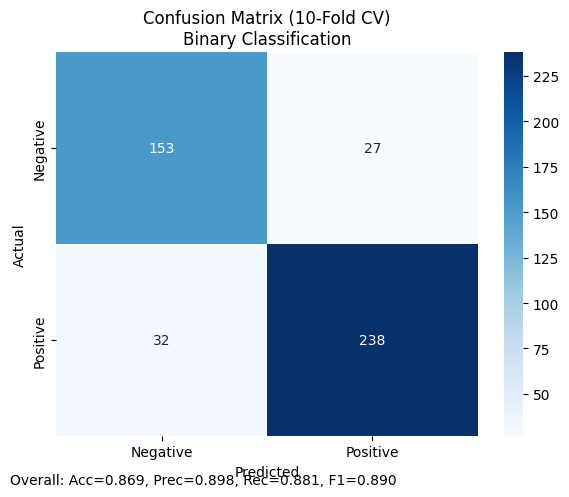

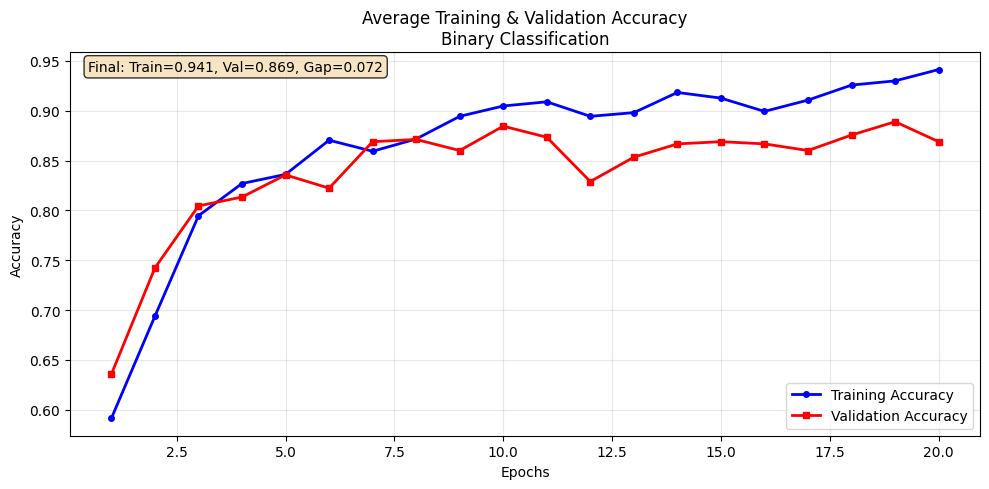

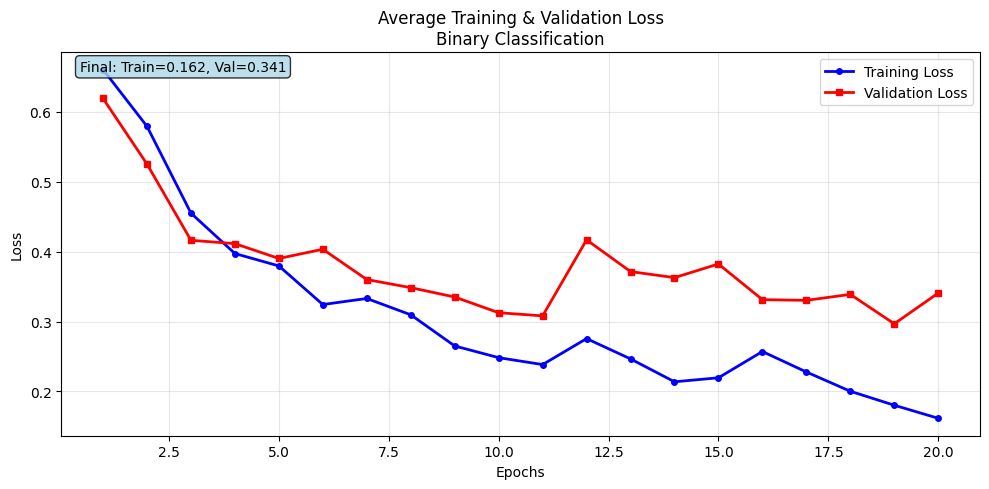

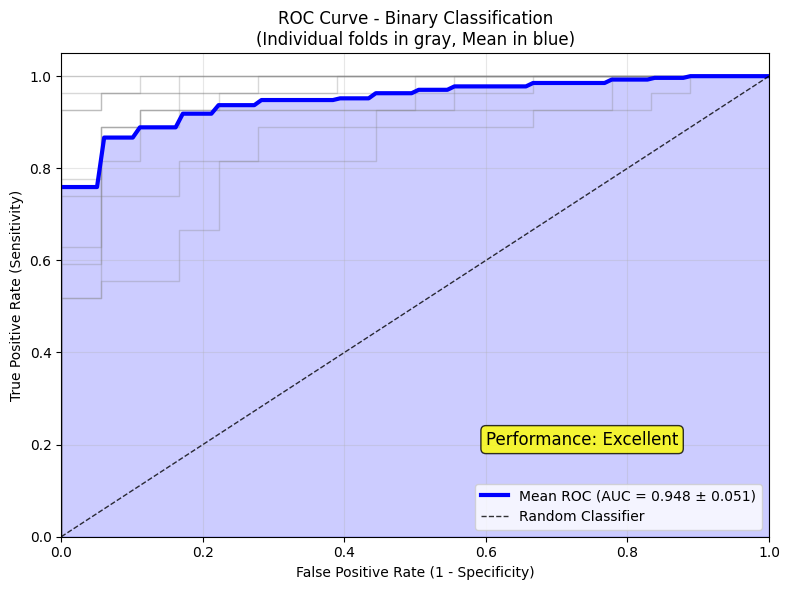

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22832\3873570050.py:209: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot(data_for_boxplot, labels=metrics, patch_artist=True)


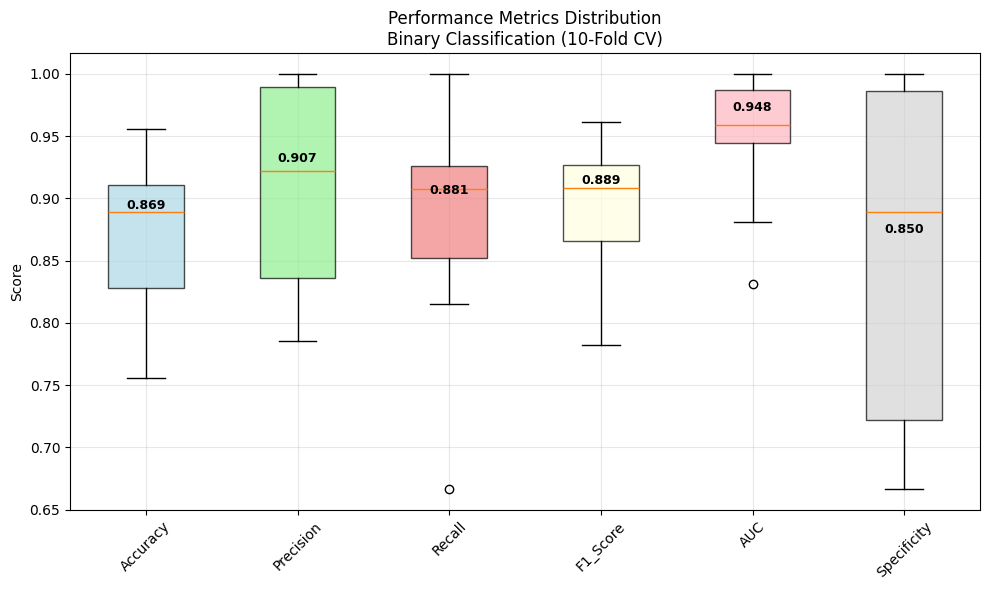


🎯 MODEL SELECTION ANALYSIS:
   Best Accuracy: Fold 10.0 (0.9556)
   Best AUC:      Fold 10.0 (1.0000)
   Best F1-Score: Fold 10.0 (0.9615)
   Consistent Models: 7 folds with accuracy > 0.836

💾 Files saved:
   - cv_results/binary_results.csv
   - cv_results/models/cnn_binary_fold_1.h5 to cnn_binary_fold_10.h5 (trained models)
   - cv_results/training_logs/fold_training_summary.csv (training summary)
   - cv_results/training_logs/epoch_by_epoch_history.csv (detailed epoch data)
   - cv_results/training_logs/training_statistics.csv (aggregated stats)
   - cv_results/training_logs/convergence_analysis.csv (convergence analysis)
   - cv_results/training_logs/class_balance_analysis.csv (class balance info)
   - cv_results/training_logs/confusion_matrix_analysis.csv (confusion matrix stats)
   - cv_results/training_logs/fold_X_detailed_history.csv (individual histories)
   - cv_results/binary_confusion_matrix.png
   - cv_results/binary_accuracy_curves.png
   - cv_results/binary_loss_curves.

In [ ]:
# Convert to DataFrame
df_results = pd.DataFrame(fold_results)
df_results.to_csv('cv_results/binary_results.csv', index=False)

# ==================== SAVE TRAINING LOGS ====================
# Save detailed training logs
df_training_logs = pd.DataFrame(training_logs)
df_training_logs.to_csv('cv_results/training_logs/fold_training_summary.csv', index=False)

# Save epoch-by-epoch data
df_epoch_data = pd.DataFrame(epoch_by_epoch_data)
df_epoch_data.to_csv('cv_results/training_logs/epoch_by_epoch_history.csv', index=False)

# Save aggregated training statistics
training_stats = {
    'total_folds': len(training_logs),
    'avg_epochs_completed': df_training_logs['epochs_completed'].mean(),
    'avg_training_time': df_training_logs['training_time'].mean(),
    'avg_final_train_acc': df_training_logs['final_train_accuracy'].mean(),
    'avg_final_val_acc': df_training_logs['final_val_accuracy'].mean(),
    'avg_best_val_acc': df_training_logs['best_val_accuracy'].mean(),
    'avg_overfitting_gap': df_training_logs['overfitting_gap'].mean(),
    'early_stopped_folds': df_training_logs['early_stopped'].sum(),
    'convergence_analysis': {
        'fastest_convergence': df_training_logs.loc[df_training_logs['best_val_accuracy_epoch'].idxmin()].to_dict(),
        'slowest_convergence': df_training_logs.loc[df_training_logs['best_val_accuracy_epoch'].idxmax()].to_dict(),
        'most_overfitted': df_training_logs.loc[df_training_logs['overfitting_gap'].idxmax()].to_dict(),
        'least_overfitted': df_training_logs.loc[df_training_logs['overfitting_gap'].idxmin()].to_dict()
    }
}

print(f"\n📝 TRAINING LOGS SAVED:")
print(f"   - cv_results/training_logs/fold_training_summary.csv (summary per fold)")
print(f"   - cv_results/training_logs/epoch_by_epoch_history.csv (detailed epoch data)")
print(f"   - cv_results/training_logs/training_statistics.json (aggregated stats)")
print(f"   - cv_results/training_logs/fold_X_history.json (individual fold histories)")

# Print summary
print(f"\n📊 BINARY CLASSIFICATION RESULTS SUMMARY:")
print(f"   Accuracy:    {df_results['Val_Accuracy'].mean():.4f} ± {df_results['Val_Accuracy'].std():.4f}")
print(f"   Precision:   {df_results['Precision'].mean():.4f} ± {df_results['Precision'].std():.4f}")
print(f"   Recall:      {df_results['Recall'].mean():.4f} ± {df_results['Recall'].std():.4f}")
print(f"   F1-Score:    {df_results['F1_Score'].mean():.4f} ± {df_results['F1_Score'].std():.4f}")
print(f"   AUC:         {df_results['AUC'].mean():.4f} ± {df_results['AUC'].std():.4f}")
print(f"   Specificity: {df_results['Specificity'].mean():.4f} ± {df_results['Specificity'].std():.4f}")
print(f"   Sensitivity: {df_results['Sensitivity'].mean():.4f} ± {df_results['Sensitivity'].std():.4f}")

print(f"\n📈 TRAINING SUMMARY:")
print(f"   Avg Epochs Completed: {df_training_logs['epochs_completed'].mean():.1f} ± {df_training_logs['epochs_completed'].std():.1f}")
print(f"   Avg Training Time:    {df_training_logs['training_time'].mean():.1f} ± {df_training_logs['training_time'].std():.1f} seconds")
print(f"   Early Stopped Folds:  {df_training_logs['early_stopped'].sum()}/10")
print(f"   Avg Overfitting Gap:  {df_training_logs['overfitting_gap'].mean():.4f} ± {df_training_logs['overfitting_gap'].std():.4f}")
print(f"   Best Val Acc Epoch:   {df_training_logs['best_val_accuracy_epoch'].mean():.1f} ± {df_training_logs['best_val_accuracy_epoch'].std():.1f}")

# ==================== VISUALIZATIONS ====================

# 1. CONFUSION MATRIX
plt.figure(figsize=(6, 5))
sum_cm = np.sum(confusion_matrices, axis=0)
sns.heatmap(sum_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (10-Fold CV)\nBinary Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Add metrics text
tn_total, fp_total, fn_total, tp_total = sum_cm.ravel()
total = tn_total + fp_total + fn_total + tp_total
acc_total = (tp_total + tn_total) / total
prec_total = tp_total / (tp_total + fp_total) if (tp_total + fp_total) > 0 else 0
rec_total = tp_total / (tp_total + fn_total) if (tp_total + fn_total) > 0 else 0
f1_total = 2 * (prec_total * rec_total) / (prec_total + rec_total) if (prec_total + rec_total) > 0 else 0

plt.figtext(0.02, 0.02, f'Overall: Acc={acc_total:.3f}, Prec={prec_total:.3f}, Rec={rec_total:.3f}, F1={f1_total:.3f}', 
            fontsize=10, ha='left')
plt.tight_layout()
plt.savefig('cv_results/binary_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. TRAINING & VALIDATION ACCURACY
plt.figure(figsize=(10, 5))

# Calculate average accuracy across folds
max_epochs = max(len(h['accuracy']) for h in all_histories)
avg_train_acc = []
avg_val_acc = []

for epoch in range(max_epochs):
    train_accs = [h['accuracy'][epoch] for h in all_histories if len(h['accuracy']) > epoch]
    val_accs = [h['val_accuracy'][epoch] for h in all_histories if len(h['val_accuracy']) > epoch]
    avg_train_acc.append(np.mean(train_accs))
    avg_val_acc.append(np.mean(val_accs))

epochs = range(1, len(avg_train_acc) + 1)
plt.plot(epochs, avg_train_acc, 'b-', label='Training Accuracy', linewidth=2, marker='o', markersize=4)
plt.plot(epochs, avg_val_acc, 'r-', label='Validation Accuracy', linewidth=2, marker='s', markersize=4)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Average Training & Validation Accuracy\nBinary Classification')
plt.legend()
plt.grid(True, alpha=0.3)

# Add final accuracy values
final_train = avg_train_acc[-1]
final_val = avg_val_acc[-1]
plt.text(0.02, 0.98, f'Final: Train={final_train:.3f}, Val={final_val:.3f}, Gap={final_train-final_val:.3f}', 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('cv_results/binary_accuracy_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. TRAINING & VALIDATION LOSS
plt.figure(figsize=(10, 5))

# Calculate average loss across folds
avg_train_loss = []
avg_val_loss = []

for epoch in range(max_epochs):
    train_losses = [h['loss'][epoch] for h in all_histories if len(h['loss']) > epoch]
    val_losses = [h['val_loss'][epoch] for h in all_histories if len(h['val_loss']) > epoch]
    avg_train_loss.append(np.mean(train_losses))
    avg_val_loss.append(np.mean(val_losses))

plt.plot(epochs, avg_train_loss, 'b-', label='Training Loss', linewidth=2, marker='o', markersize=4)
plt.plot(epochs, avg_val_loss, 'r-', label='Validation Loss', linewidth=2, marker='s', markersize=4)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Average Training & Validation Loss\nBinary Classification')
plt.legend()
plt.grid(True, alpha=0.3)

# Add final loss values
final_train_loss = avg_train_loss[-1]
final_val_loss = avg_val_loss[-1]
plt.text(0.02, 0.98, f'Final: Train={final_train_loss:.3f}, Val={final_val_loss:.3f}', 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.savefig('cv_results/binary_loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. ROC CURVE
plt.figure(figsize=(8, 6))

# Plot ROC for each fold (light lines)
for i, roc_data in enumerate(all_roc_data):
    plt.plot(roc_data['fpr'], roc_data['tpr'], alpha=0.3, color='gray', linewidth=1)

# Calculate and plot average ROC
# Interpolate all ROC curves to common FPR points
mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []

for roc_data in all_roc_data:
    tprs.append(np.interp(mean_fpr, roc_data['fpr'], roc_data['tpr']))
    aucs.append(roc_data['auc'])

mean_tpr = np.mean(tprs, axis=0)
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

# Fill area under average ROC curve
plt.fill_between(mean_fpr, mean_tpr, alpha=0.2, color='blue')

plt.plot(mean_fpr, mean_tpr, color='blue', linewidth=3,
         label=f'Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.8, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve - Binary Classification\n(Individual folds in gray, Mean in blue)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Add AUC interpretation
auc_interpretation = ""
if mean_auc >= 0.9:
    auc_interpretation = "Excellent"
elif mean_auc >= 0.8:
    auc_interpretation = "Good"
elif mean_auc >= 0.7:
    auc_interpretation = "Fair"
elif mean_auc >= 0.6:
    auc_interpretation = "Poor"
else:
    auc_interpretation = "Fail"

plt.text(0.6, 0.2, f'Performance: {auc_interpretation}', fontsize=12, 
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

plt.tight_layout()
plt.savefig('cv_results/binary_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. BONUS: Performance Metrics Comparison
plt.figure(figsize=(10, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC', 'Specificity']
metric_cols = ['Val_Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC', 'Specificity']

# Box plot for all metrics
data_for_boxplot = [df_results[col].values for col in metric_cols]
box_plot = plt.boxplot(data_for_boxplot, labels=metrics, patch_artist=True)

# Color the boxes
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow', 'lightpink', 'lightgray']
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.ylabel('Score')
plt.title('Performance Metrics Distribution\nBinary Classification (10-Fold CV)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Add mean values on top of boxes
for i, col in enumerate(metric_cols):
    mean_val = df_results[col].mean()
    plt.text(i+1, mean_val + 0.02, f'{mean_val:.3f}', ha='center', va='bottom', 
             fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('cv_results/binary_metrics_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ==================== MODEL SELECTION ====================

print(f"\n🎯 MODEL SELECTION ANALYSIS:")

# Best model by different criteria
best_acc_idx = df_results['Val_Accuracy'].idxmax()
best_auc_idx = df_results['AUC'].idxmax()
best_f1_idx = df_results['F1_Score'].idxmax()

print(f"   Best Accuracy: Fold {df_results.iloc[best_acc_idx]['Fold']} ({df_results.iloc[best_acc_idx]['Val_Accuracy']:.4f})")
print(f"   Best AUC:      Fold {df_results.iloc[best_auc_idx]['Fold']} ({df_results.iloc[best_auc_idx]['AUC']:.4f})")
print(f"   Best F1-Score: Fold {df_results.iloc[best_f1_idx]['Fold']} ({df_results.iloc[best_f1_idx]['F1_Score']:.4f})")

# Most consistent models (low variance)
acc_mean = df_results['Val_Accuracy'].mean()
acc_std = df_results['Val_Accuracy'].std()
consistent_models = df_results[df_results['Val_Accuracy'] > (acc_mean - acc_std/2)]
print(f"   Consistent Models: {len(consistent_models)} folds with accuracy > {acc_mean - acc_std/2:.3f}")

print(f"\n💾 Files saved:")
print(f"   - cv_results/binary_results.csv")
print(f"   - cv_results/models/cnn_binary_fold_1.h5 to cnn_binary_fold_10.h5 (trained models)")
print(f"   - cv_results/training_logs/fold_training_summary.csv (training summary)")
print(f"   - cv_results/training_logs/epoch_by_epoch_history.csv (detailed epoch data)")
print(f"   - cv_results/training_logs/training_statistics.csv (aggregated stats)")
print(f"   - cv_results/training_logs/convergence_analysis.csv (convergence analysis)")
print(f"   - cv_results/training_logs/class_balance_analysis.csv (class balance info)")
print(f"   - cv_results/training_logs/confusion_matrix_analysis.csv (confusion matrix stats)")
print(f"   - cv_results/training_logs/fold_X_detailed_history.csv (individual histories)")
print(f"   - cv_results/binary_confusion_matrix.png")
print(f"   - cv_results/binary_accuracy_curves.png")
print(f"   - cv_results/binary_loss_curves.png")
print(f"   - cv_results/binary_roc_curve.png")
print(f"   - cv_results/binary_metrics_distribution.png")

print(f"\n🔍 TRAINING LOG ANALYSIS EXAMPLES:")
print(f"   # Load epoch-by-epoch data")
print(f"   df_epochs = pd.read_csv('cv_results/training_logs/epoch_by_epoch_history.csv')")
print(f"   # Filter binary classification data")
print(f"   binary_epochs = df_epochs[df_epochs['classification_type'] == 'binary']")
print(f"   # Analyze convergence for specific fold")
print(f"   fold_1_data = binary_epochs[binary_epochs['fold'] == 1]")
print(f"   # Load training summary for analysis")
print(f"   df_summary = pd.read_csv('cv_results/training_logs/fold_training_summary.csv')")
print(f"   # Load convergence analysis")
print(f"   df_convergence = pd.read_csv('cv_results/training_logs/convergence_analysis.csv')")
print(f"   fastest_fold = df_convergence[df_convergence['analysis_type'] == 'fastest_convergence']['fold'].iloc[0]")

print(f"\n🔍 BINARY-SPECIFIC ANALYSIS EXAMPLES:")
print(f"   # Load fold training summary for binary metrics")
print(f"   df_summary = pd.read_csv('cv_results/training_logs/fold_training_summary.csv')")
print(f"   # Analyze precision vs recall trade-off")
print(f"   high_precision_folds = df_summary[df_summary['final_precision'] > 0.9]")
print(f"   high_recall_folds = df_summary[df_summary['final_recall'] > 0.9]")
print(f"   # Load class balance analysis")
print(f"   df_balance = pd.read_csv('cv_results/training_logs/class_balance_analysis.csv')")
print(f"   # Load confusion matrix analysis")
print(f"   df_confusion = pd.read_csv('cv_results/training_logs/confusion_matrix_analysis.csv')")
print(f"   print('Average false positives:', df_confusion[df_confusion['metric'] == 'avg_false_positives']['value'].iloc[0])")

print(f"\n🔄 Model Loading Examples:")
print(f"   from tensorflow.keras.models import load_model")
print(f"   # Load best model by different criteria")
print(f"   best_acc_fold = df_convergence[df_convergence['analysis_type'] == 'best_performer']['fold'].iloc[0]")
print(f"   best_precision_fold = df_convergence[df_convergence['analysis_type'] == 'best_precision']['fold'].iloc[0]")
print(f"   best_recall_fold = df_convergence[df_convergence['analysis_type'] == 'best_recall']['fold'].iloc[0]")
print(f"   best_f1_fold = df_convergence[df_convergence['analysis_type'] == 'best_f1']['fold'].iloc[0]")
print(f"   best_auc_fold = df_convergence[df_convergence['analysis_type'] == 'best_auc']['fold'].iloc[0]")
print(f"   # Load specific model")
print(f"   best_model = load_model(f'cv_results/models/cnn_binary_fold_{{best_acc_fold}}.h5')")
print(f"   # Prediction for binary classification")
print(f"   predictions = best_model.predict(new_data)")
print(f"   predicted_classes = (predictions > 0.5).astype(int)")

print(f"\n🎯 THRESHOLD OPTIMIZATION EXAMPLE:")
print(f"   # Analyze different thresholds using training logs")
print(f"   from sklearn.metrics import precision_recall_curve")
print(f"   # Load individual fold detailed history if needed")
print(f"   fold_1_history = pd.read_csv('cv_results/training_logs/fold_1_detailed_history.csv')")
print(f"   # Use ROC data for threshold selection")
print(f"   # Find optimal threshold for precision-recall balance")

print(f"\n✅ Binary classification cross-validation completed!")
print("=" * 60)